# Unbinned analysis: localizing a source

Tutorial 04 built a Poisson likelihood over *binned* counts: photons were sorted into bins of some observable, and the observed counts per bin were compared against the model's prediction. Binning is convenient, but it throws away information -- two events landing anywhere in the same bin are treated as identical -- and when the data is sparse or the quantity of interest is continuous, that can matter. (In principle you could chase the same effect by shrinking the bins until they oversample the instrument's own angular or energy resolution, but for a detector with several correlated observables that's not always computationally feasible.) Here we'll run the same kind of forward-folding maximum-likelihood analysis without ever building a histogram: an *unbinned* (event-by-event) likelihood, applied to the problem this notebook is named after -- figuring out *where in the sky* a source is, from the individual reconstructed direction of every detected photon.

## From binned to unbinned

In a bin where $\lambda_k(\Theta)$ events are expected, the observed count $N_k$ is Poisson-distributed:

$$P(N_k;\lambda_k) = \frac{e^{-\lambda_k}\lambda_k^{N_k}}{N_k!}$$

This holds for any $\lambda_k$, including arbitrarily small ones -- as $\lambda_k \to 0$ it just says the bin is overwhelmingly likely to be empty. So nothing stops us from shrinking every bin until each one holds either 0 or 1 events (an occupied bin can always be split further without merging two events together). With only two possible outcomes per bin, the full likelihood -- the product over every bin -- splits in two:

$$\mathcal{L}(\Theta) = \prod_{k \,:\, N_k = 0} \underbrace{e^{-\lambda_k(\Theta)}}_{P(0;\lambda_k)} \;\; \times \!\!\prod_{k \,:\, N_k = 1} \underbrace{\lambda_k(\Theta)\, e^{-\lambda_k(\Theta)}}_{P(1;\lambda_k)}$$

and the log-likelihood turns the products into sums:

$$\log\mathcal{L}(\Theta) = -\!\!\sum_{k \,:\, N_k = 0}\!\! \lambda_k(\Theta) \; - \!\!\sum_{k \,:\, N_k = 1}\!\! \lambda_k(\Theta) \; + \!\!\sum_{k \,:\, N_k = 1}\!\! \log\left(\lambda_k(\Theta)\right)$$

The first two sums together range over *every* bin (each one is either empty or occupied), so they combine into $-\sum_k \lambda_k(\Theta)$. As the bins keep shrinking, that sum converges -- exactly, not approximately, since we've only relabeled terms so far -- to the integral of the expectation density over the whole observable space, $\mu(\Theta) = \int \lambda(x;\Theta)\,dx$: the total number of events the hypothesis predicts. What's left is:

$$\log \mathcal{L}(\Theta) = -\mu(\Theta) + \sum_i \log\left(\lambda(x_i;\Theta)\right)$$

where $\lambda(x;\Theta)$ is the *expectation density* -- expected events per unit of $x$ -- and the sum runs over every individually observed value $x_i$ (for us, the reconstructed direction of each detected photon), not over bins. This is exactly what `gammaraytoys.analysis.unbinned_log_likelihood` computes, given the expectation density evaluated at each data point and the total expected number of events:

```python
unbinned_log_likelihood(expectation_density, total_expectation)
```

## Setting up the toy problem

We'll reuse the same tracker detector as the earlier tutorials, along with the chirality-resolved imaging response -- effective area $A_{eff}(\nu)$ and the ARM/$\Phi$/$\zeta$ probability density $\mathrm{pdf}(\mathrm{ARM},\Phi,\zeta\,|\,\nu)$ -- generated in `docs/tutorials/instrument_response` (`response_imaging_chiral_relative_1MeV_traddet.h5`). This plays the same role here that the energy-relative response (`response_energy_relative_onaxis_traddet.h5`) played in tutorial 04: there, the response was reparametrized from $(E_i,E_m)$ into $(E_i,\Delta E_m/E_i)$, a coordinate relative to the *true* photon energy; here it's reparametrized from $(\nu,\Phi,\Psi)$ into $(\nu,\Phi,\mathrm{ARM})$, a coordinate relative to the *hypothesized source direction*. Both `Aeff` and `chiral_img_pdf` are stored on disk, and held in memory, as ordinary histograms over a finite grid -- they're interpolated on the fly every time we evaluate them at a hypothesis, not pre-interpolated into some continuous function ahead of time.

In [1]:
from gammaraytoys import ToyTracker2D
from gammaraytoys.detectors import Simulator, SimpleTraditionalReconstructor, PointSource, MonoenergeticSpectrum
from gammaraytoys.analysis import unbinned_log_likelihood, LogLikeGrid
from histpy import Histogram, Axis
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

# Detector
det = ToyTracker2D(material = 'Ge',
                   layer_length = 10*u.m,
                   layer_positions = np.append(300, np.arange(0,10,1))*u.cm,
                   layer_thickness = 1*u.cm,
                   energy_resolution = 0.03,
                   energy_threshold = 20*u.keV)

# Chirality-resolved imaging response, built for a 1 MeV on-axis-centered source
Aeff = Histogram.open("instrument_response/response_imaging_chiral_relative_1MeV_traddet.h5", name = 'Aeff')
chiral_img_pdf = Histogram.open("instrument_response/response_imaging_chiral_relative_1MeV_traddet.h5", name = 'PDF')

The response was built without singling out a particular source polarization -- it's tabulated over a chirality axis `k` meant for a source with some preferred handedness. Our injected source below is unpolarized (each detected photon's own chirality is drawn independently, 50/50), so we'll always evaluate the response at `k = 0`, right at the midpoint between the two chirality bins -- `Histogram.interp` will linearly average them for us.

### Simulating the (unbinned) data

Let's place a monoenergetic point source at some true off-axis angle and simulate the individually detected photons. Instead of histogramming the result, we'll keep a plain list of the two angles the Compton kinematics and hit positions give us for each event -- the scattering angle $\Phi$ and the azimuth $\Psi$ -- exactly as a real event-by-event analysis would receive them.

In [2]:
import contextlib, io

np.random.seed(0)

Nu_true = 30*u.deg
flux = 1.5e-3/u.cm/u.s
duration = 5*u.minute

source = PointSource(offaxis_angle = Nu_true,
                     spectrum = MonoenergeticSpectrum(energy = 1*u.MeV),
                     flux = flux)

reco = SimpleTraditionalReconstructor()
sims = Simulator(detector = det, sources = source, reconstructor = reco)

signal_psi = []
signal_phi = []
with contextlib.redirect_stderr(io.StringIO()): # Silence the progress bar
    for sim_event, reco_event in sims.run_events(duration = duration):
        if reco_event.triggered:
            signal_psi.append(reco_event.psi.to_value(u.deg))
            signal_phi.append(reco_event.phi.to_value(u.deg))
signal_psi = u.Quantity(signal_psi, u.deg)
signal_phi = u.Quantity(signal_phi, u.deg)

print(f"{signal_psi.size} signal photons detected")

49 signal photons detected


As always, no real detector is background free. We'll assume a background that's flat across the whole field of view, and simulate it event-by-event too:

In [3]:
bkg_rate = 0.5*u.Hz  # Flat over the full (Psi, Phi) sky

n_bkg = np.random.poisson((bkg_rate*duration).to_value(''))
bkg_psi = np.random.uniform(-180, 180, size = n_bkg)*u.deg
bkg_phi = np.random.uniform(0, 180, size = n_bkg)*u.deg

print(f"{n_bkg} background photons detected")

138 background photons detected


187 total photons in the dataset


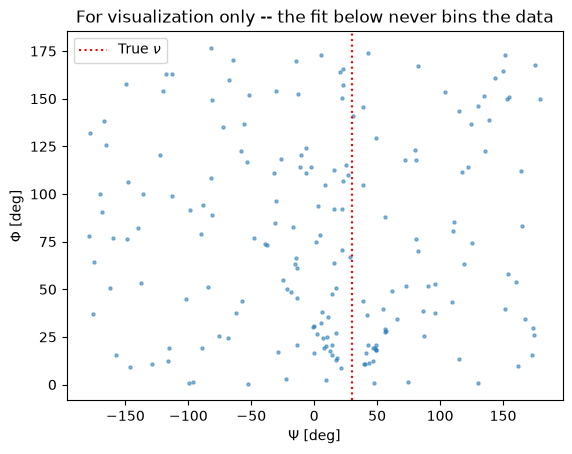

In [4]:
# The "data" is simply the list of (Psi, Phi) pairs -- no histogram involved.
data_psi = u.Quantity(np.concatenate([signal_psi, bkg_psi]))
data_phi = u.Quantity(np.concatenate([signal_phi, bkg_phi]))

print(f"{data_psi.size} total photons in the dataset")

# Just for visualization -- the fit below never bins the data
fig,ax = plt.subplots()
ax.scatter(data_psi.to_value(u.deg), data_phi.to_value(u.deg), s = 5, alpha = .5)
ax.axvline(Nu_true.to_value(u.deg), color = 'red', ls = ':', label = 'True $\\nu$')
ax.set_xlabel("$\\Psi$ [deg]")
ax.set_ylabel("$\\Phi$ [deg]")
ax.set_title("For visualization only -- the fit below never bins the data")
ax.legend();

## Building the expectation density

Just like in the binned case, we need a model for the expected number of events, but now as a density over the two observed angles, $\lambda(\Psi,\Phi;\Theta)$, together with its integral $\mu(\Theta)$.

The response is tabulated in terms of the ARM (the difference between the Compton-kinematics scattering angle $\Phi$ and the geometric angle $|\Psi-\nu|$ implied by a hypothesized source position $\nu$) and the handedness $\zeta$ of that geometric angle, rather than $\Psi$ directly. Given a position hypothesis $\nu^{hyp}$, both are deterministic functions of the observed $(\Psi,\Phi)$ -- there's no unknown to integrate over, unlike the true photon energy in a spectral fit, since here the hypothesis *is* the geometric quantity the transformation needs. (For a spatially extended source you'd instead integrate the expectation over every possible true direction, weighted by the source's own spatial brightness distribution -- the direct analog of integrating over true photon energy for a continuous spectrum. A point source is a Dirac delta in direction, so that integral collapses trivially to evaluating everything at $\nu^{hyp}$, the same simplification a monoenergetic line gave us for the energy integral.)

$$\lambda_{sig}(\Psi,\Phi;\Theta) = F \cdot T \cdot A_{eff}(\nu^{hyp}) \cdot \mathrm{pdf}\big(\mathrm{ARM}(\Psi,\Phi,\nu^{hyp}),\, \Phi,\, \zeta(\Psi,\nu^{hyp}) \,\big|\, \nu^{hyp}\big)$$

where $F$ is the flux and $T$ the exposure time. Events whose ARM or $\Phi$ fall outside the range the response was tabulated over get zero density -- they're geometrically inconsistent with a source at $\nu^{hyp}$.

For the flat background, the density is just the total expected background spread evenly over the full $(\Psi,\Phi)$ sky, $\lambda_{bkg}(\Psi,\Phi) = N_{bkg}(\Theta)\,/\,(2\pi \cdot \pi)$.

In [5]:
def phipsi_to_armzeta(nu, psi, phi):
    """Geometric ARM and zeta implied by a hypothesized source position nu"""

    psi = u.Quantity(psi).copy()

    # Account for angle wrapping
    psi[psi > nu + 180*u.deg] -= 360*u.deg
    psi[psi < nu - 180*u.deg] += 360*u.deg

    zeta = 2*(nu > psi) - 1
    arm = np.abs(psi - nu) - phi

    return arm, zeta

sky_area = (360*u.deg).to_value(u.rad) * (180*u.deg).to_value(u.rad)

def signal_expectation(psi, phi, flux_hyp, Nu_hyp):
    """Signal expectation density [1/rad^2] at each observed (psi, phi), and the total expected signal counts"""

    arm, zeta = phipsi_to_armzeta(Nu_hyp, psi, phi)

    in_response = ((arm > chiral_img_pdf.axes['ARM'].lo_lim) & (arm < chiral_img_pdf.axes['ARM'].hi_lim) &
                   (phi > chiral_img_pdf.axes['Phi'].lo_lim) & (phi < chiral_img_pdf.axes['Phi'].hi_lim))

    density = np.zeros(psi.size)/u.rad/u.rad

    # histpy's interp() needs matching-shape coordinates across every axis of
    # a multi-dimensional histogram, so broadcast the two hypothesis
    # coordinates (Nu_hyp and chirality=0) to match the per-event arrays.
    n_in = np.count_nonzero(in_response)
    Nu_hyp_arr = np.full(n_in, Nu_hyp.to_value(u.deg))*u.deg
    chirality_arr = np.zeros(n_in)

    density[in_response] = chiral_img_pdf.interp(Nu_hyp_arr, chirality_arr, phi[in_response], arm[in_response], zeta[in_response])

    total_signal = (flux_hyp * duration * Aeff.interp(Nu_hyp, 0)).to_value('')

    return total_signal*density, total_signal

def bkg_expectation(psi, phi, bkg_rate_hyp):
    """Background expectation density [1/rad^2] at each observed (psi, phi), and the total expected background counts"""

    total_bkg = (bkg_rate_hyp * duration).to_value('')

    density = np.full(psi.size, total_bkg/sky_area)/u.rad/u.rad

    return density, total_bkg

## The unbinned likelihood function

In [6]:
def log_like_fun(flux_hyp, Nu_hyp, bkg_rate_hyp):

    sig_density, mu_sig = signal_expectation(data_psi, data_phi, flux_hyp, Nu_hyp)
    bkg_density, mu_bkg = bkg_expectation(data_psi, data_phi, bkg_rate_hyp)

    total_density = (sig_density + bkg_density).to_value(1/u.rad/u.rad)
    total_expectation = mu_sig + mu_bkg

    return unbinned_log_likelihood(total_density, total_expectation)

Just as with the binned analysis, `LogLikeGrid` lets us scan a grid of hypotheses -- flux, source position, and background rate -- and find the maximum-likelihood estimate, all without ever putting a single event in a bin:

In [7]:
log_like = LogLikeGrid([Axis(np.geomspace(1e-3, 1e-2, 25)/u.cm/u.s, label = 'flux', scale = 'log'),
                        Axis(np.linspace(26, 34, 25)*u.deg, label = 'Nu'),
                        Axis(np.geomspace(0.1, 2, 15)*u.Hz, label = 'bkg', scale = 'log')])

with contextlib.redirect_stderr(io.StringIO()): # Silence the progress bar
    log_like.compute(log_like_fun)

In [8]:
popt = log_like.optimal_parameters()
print(f"Flux best estimate     = {popt[0]:.2}  (injected {flux:.2})")
print(f"Position best estimate = {popt[1]:.3}  (injected {Nu_true:.3})")
print(f"Bkg rate best estimate = {popt[2]:.2}  (injected {bkg_rate:.2})")

Flux best estimate     = 0.0015 1 / (cm s)  (injected 0.0015 1 / (cm s))
Position best estimate = 29.8 deg  (injected 30.0 deg)
Bkg rate best estimate = 0.5 Hz  (injected 0.5 Hz)


As with the nuisance background parameter in the binned analysis, we can profile it out to visualize the flux-vs-position likelihood surface -- the TS map this notebook is named after:

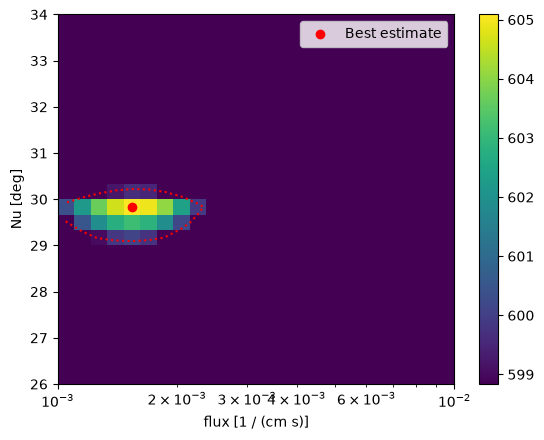

In [9]:
profile_log_like = log_like.maximum('bkg')
profile_log_like.plot_ts()

## Detection significance

To turn this into a detection significance we need a null hypothesis. As before, the natural choice is background-only -- flux fixed to 0:

In [10]:
def log_like0_fun(bkg_rate_hyp):
    bkg_density, mu_bkg = bkg_expectation(data_psi, data_phi, bkg_rate_hyp)
    return unbinned_log_likelihood(bkg_density.to_value(1/u.rad/u.rad), mu_bkg)

log_like0 = LogLikeGrid(Axis(np.geomspace(0.1, 2, 15)*u.Hz, label = 'bkg', scale = 'log'))
with contextlib.redirect_stderr(io.StringIO()): # Silence the progress bar
    log_like0.compute(log_like0_fun)

In [11]:
from scipy.stats import chi2, norm

ts_detection = 2*(log_like.maximum() - log_like0.maximum())
pvalue = chi2.sf(ts_detection, df = log_like.ndof - log_like0.ndof)
significance = norm.isf(pvalue)

print(f"TS = {ts_detection:.1f}")
print(f"Significance = {significance:.1f} sigma")

TS = 138.2
Significance = 11.5 sigma


The imaging response's angular resolution sets a floor on how precisely the position can be pinned down no matter how bright the source is -- notice how much wider the TS map is along $\nu$ than a point. Try lowering `flux`, `duration`, or raising `bkg_rate` a few cells above (and re-running the notebook) to see the position uncertainty grow and the significance degrade as the signal becomes marginal.

<div class="alert alert-block alert-info">
<b>Exercise: Binned vs. unbinned</b>

Repeat this analysis, but this time bin <code>data_psi</code> and <code>data_phi</code> into a 2D <code>Histogram</code> and fit it with <code>poisson_binned_log_likelihood</code> instead (you'll need to integrate the signal and background expectation densities over each bin, the way <code>SpectralResponse.expected_counts</code> does for the energy case). Compare the best-fit position and the TS you get from the binned vs. the unbinned approach. Then progressively lower the injected flux (or the exposure time) until only a handful of signal photons remain: which approach holds up better with very little data, and why?
</div>

<div class="alert alert-block alert-info">
<b>Exercise: Using the source's polarization</b>

We ignored chirality entirely, evaluating the response at <code>k = 0</code> regardless of each event's own reconstructed handedness. A polarized source leaves a genuine asymmetry in the distribution of <code>zeta</code> across events, which the response's <code>k</code> axis is built to capture. Try injecting a source with <code>chirality_degree</code> close to 1 in <code>PointSource</code>, and extend <code>signal_expectation</code> to evaluate the response at the <code>k</code> bin matching each event's own chirality instead of averaging it away. Does using it improve the localization, the significance, both, or neither?
</div>